# Statistical Rethinking ch12 — Reedfrogs intro multilevel (binomial GLMM)

Frequentist port of McElreath's reedfrogs tank-survival example (*Statistical
Rethinking* 2nd ed., ch. 13 in the 2020 print / ch. 12 in the 2026 lectures),
fit with **interlace.glmer** and validated against `lme4::glmer`.

**Dataset.** 48 artificial ponds (*tanks*) of *Hyla chrysoscelis* tadpoles
(Vonesh & Bolker, 2005). Each tank starts with `density` ∈ {10, 25, 35} tadpoles
and is crossed with `pred` ∈ {no, pred} and `size` ∈ {big, small}; we observe
`surv` survivors at the end of the experiment.

**Why a varying intercept on `tank`?** With one observation per tank,
the intercept absorbs unmodelled tank-level heterogeneity (an
*observation-level random effect*). The hierarchy is

$$ \mathrm{surv}_i \sim \mathrm{Binomial}(\mathrm{density}_i,\; p_i) $$
$$ \mathrm{logit}\,p_i = \alpha + \alpha_{\mathrm{tank}[i]} + X_i \beta,\quad \alpha_{\mathrm{tank}[i]} \sim \mathcal{N}(0,\;\sigma_\alpha^2). $$

Four nested fits, in increasing complexity:

| Model | Linear predictor                  |
|-------|-----------------------------------|
| M0    | `1 + (1\|tank)`                    |
| M1    | `pred + (1\|tank)`                 |
| M2    | `size + (1\|tank)`                 |
| M3    | `pred * size + (1\|tank)`          |

Each is compared against the lme4 reference fixture in `tests/fixtures/sr_12_reedfrogs_M*_results.json`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotnine as p9
from plotnine import (
    ggplot, aes,
    geom_point, geom_segment, geom_hline, geom_vline, geom_text,
    facet_grid, facet_wrap, labs, theme_bw, theme, element_text,
    scale_x_continuous, scale_y_continuous, coord_cartesian,
)

import interlace

FIXTURE_DIR = Path("../../tests/fixtures")


## 1. Data preparation

In [2]:
df = pd.read_csv(FIXTURE_DIR / "sr_12_reedfrogs_data.csv")
df["tank"] = np.arange(1, len(df) + 1)
df["proportion"] = df["surv"] / df["density"]
df["fail"] = df["density"] - df["surv"]
print(f"Tanks       : {len(df)}")
print(f"density mix : {df['density'].value_counts().to_dict()}")
print(f"pred levels : {df['pred'].value_counts().to_dict()}")
print(f"size levels : {df['size'].value_counts().to_dict()}")
df.head()


Tanks       : 48
density mix : {10: 16, 25: 16, 35: 16}
pred levels : {'no': 24, 'pred': 24}
size levels : {'big': 24, 'small': 24}


,density,pred,size,surv,propsurv,tank,proportion,fail
0,10,no,big,9,0.9,1,0.9,1
1,10,no,big,10,1.0,2,1.0,0
2,10,no,big,7,0.7,3,0.7,3
3,10,no,big,10,1.0,4,1.0,0
4,10,no,small,9,0.9,5,0.9,1


## 2. EDA — survival proportion by treatment

A clear story falls out before any modelling: predator presence drops survival
sharply, especially in small tadpoles.

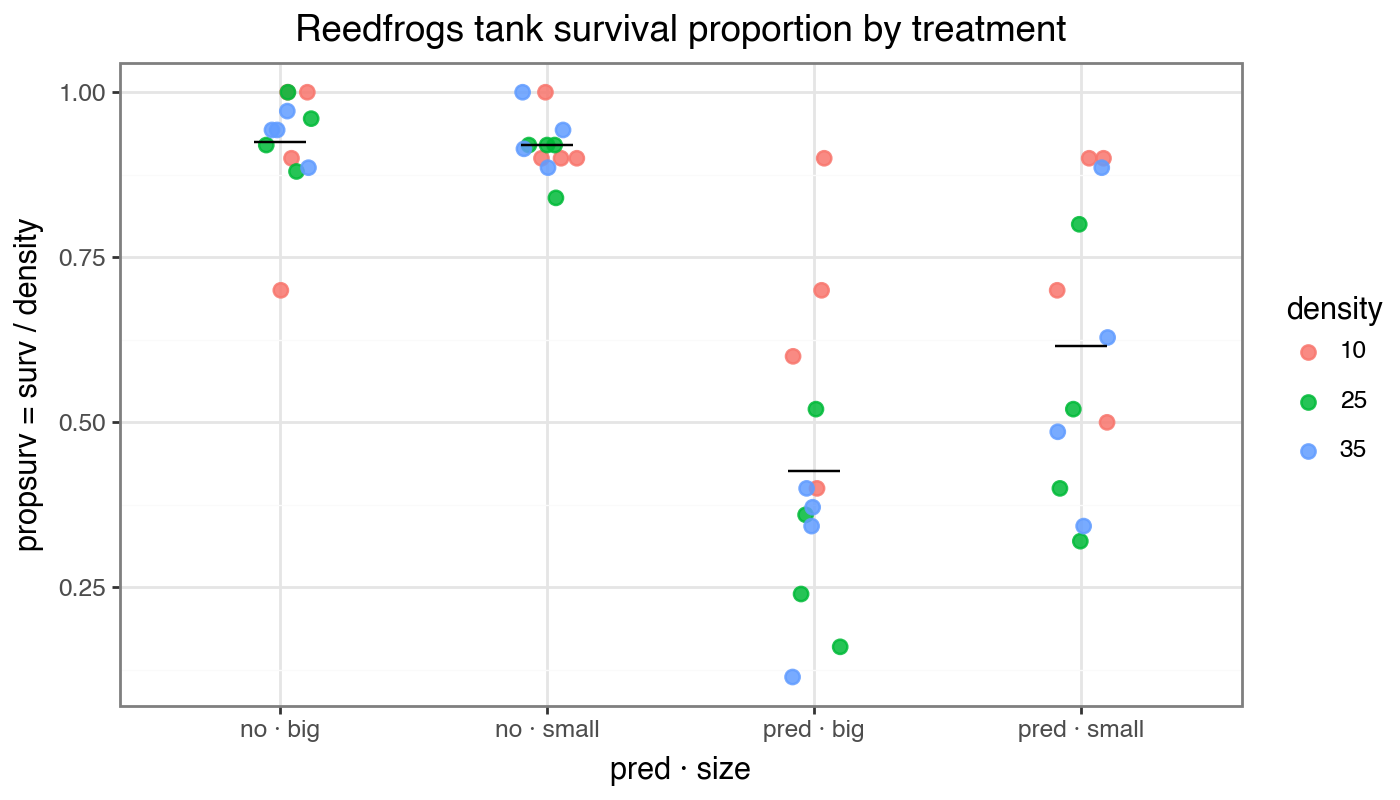

In [3]:
plot_df = df.assign(
    treatment=df["pred"].astype(str) + " · " + df["size"].astype(str),
    density_str=df["density"].astype(str),
)

(
    ggplot(plot_df, aes("treatment", "proportion", color="density_str"))
    + p9.geom_jitter(width=0.12, height=0, size=2.4, alpha=0.85)
    + p9.stat_summary(fun_y=np.mean, geom="point", shape="_", size=10, color="black")
    + labs(
        title="Reedfrogs tank survival proportion by treatment",
        x="pred · size",
        y="propsurv = surv / density",
        color="density",
    )
    + theme_bw()
    + theme(figure_size=(7, 4))
)


## 3. Three views of the intercept (Section 13.1)

Following the chapter's pedagogy, fit three estimators of the per-tank intercept
to set up the shrinkage figure:

- **Complete pooling** — single grand intercept $\alpha$. Wastes between-tank
  signal.
- **No pooling** — empirical logit per tank. Unstable for small `density`,
  divergent for `propsurv ∈ {0, 1}`.
- **Partial pooling** — multilevel `(1 | tank)`, shrinks each tank toward the
  grand mean by a factor that depends on its information.

In [4]:
# Complete pooling: single binomial GLM intercept (success / failure)
import statsmodels.api as sm

y_mat = df[["surv", "fail"]].to_numpy()
cp = sm.GLM(y_mat, np.ones((len(df), 1)), family=sm.families.Binomial()).fit()
alpha_cp = float(cp.params[0])
print(f"Complete pooling intercept (logit p̄) : {alpha_cp:+.4f}  -> p̄ = {1/(1+np.exp(-alpha_cp)):.3f}")


Complete pooling intercept (logit p̄) : +0.8430  -> p̄ = 0.699


In [5]:
# No pooling: per-tank empirical logit (with Haldane 0.5 correction for 0/density)
def empirical_logit(s, n):
    p = (s + 0.5) / (n + 1.0)
    return np.log(p / (1 - p))

df["logit_np"] = empirical_logit(df["surv"].to_numpy(), df["density"].to_numpy())
df.head()


,density,pred,size,surv,propsurv,tank,proportion,fail,logit_np
0,10,no,big,9,0.9,1,0.9,1,1.845827
1,10,no,big,10,1.0,2,1.0,0,3.044522
2,10,no,big,7,0.7,3,0.7,3,0.762140
3,10,no,big,10,1.0,4,1.0,0,3.044522
4,10,no,small,9,0.9,5,0.9,1,1.845827


## 4. M0 — partial-pooling intercept-only varying intercept (m13.2)

`interlace.glmer` with `family="binomial"`, `groups="tank"`, and trial counts
passed via `weights=density`.

In [6]:
def glmer_binom(formula: str, data: pd.DataFrame):
    return interlace.glmer(
        formula,
        data=data,
        family="binomial",
        groups="tank",
        weights=data["density"].to_numpy(dtype=float),
    )

M0 = glmer_binom("proportion ~ 1", df)
print(M0.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: proportion ~ 1

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                  1.3810       0.2478     5.5720

Random effects:
  tank            Var: 2.465124  SD: 1.570071  (n=48)

Number of obs: 48, groups: tank: 48
AIC: 271.58  BIC: 275.32  logLik: -133.79
Optimizer: converged


In [7]:
r_M0 = json.loads((FIXTURE_DIR / "sr_12_reedfrogs_M0_results.json").read_text())

print("=== M0 validation against lme4 (bobyqa) ===")
print(f"{'parameter':<22} {'interlace':>11} {'R lme4':>11} {'diff':>11}")
print("-" * 60)
print(f"{'(Intercept)':<22} {float(M0.fe_params['Intercept']):>11.4f} "
      f"{r_M0['fixed_effects']['(Intercept)']:>11.4f} "
      f"{float(M0.fe_params['Intercept']) - r_M0['fixed_effects']['(Intercept)']:>+11.2e}")
print(f"{'sigma_tank^2':<22} {float(M0.variance_components['tank']):>11.4f} "
      f"{r_M0['variance_components']['tank']:>11.4f} "
      f"{(float(M0.variance_components['tank']) - r_M0['variance_components']['tank']) / r_M0['variance_components']['tank']:>+11.2%}")
print(f"{'logLik':<22} {float(M0.llf):>11.4f} "
      f"{r_M0['loglik']:>11.4f} "
      f"{float(M0.llf) - r_M0['loglik']:>+11.2e}")

# BLUP correlation
r_re = r_M0["ranef_tank"]
levels = sorted(int(k) for k in r_re)
r_arr = np.array([r_re[str(i)] for i in levels])
py_re = M0.random_effects["tank"]
py_arr = np.array([float(py_re.loc[i]) for i in levels])
print(f"{'BLUP corr':<22} {np.corrcoef(r_arr, py_arr)[0, 1]:>11.4f}")


=== M0 validation against lme4 (bobyqa) ===
parameter                interlace      R lme4        diff
------------------------------------------------------------
(Intercept)                 1.3810      1.3786   +2.33e-03
sigma_tank^2                2.4651      2.4587      +0.26%
logLik                   -133.7895   -133.7912   +1.72e-03
BLUP corr                   1.0000


### Shrinkage figure (Figure 13.1)

Empirical no-pooling estimate vs partial-pooling BLUP on the logit scale,
sized by `density`. Tanks with fewer tadpoles are pulled harder toward the grand
mean — the canonical multilevel shrinkage signature.

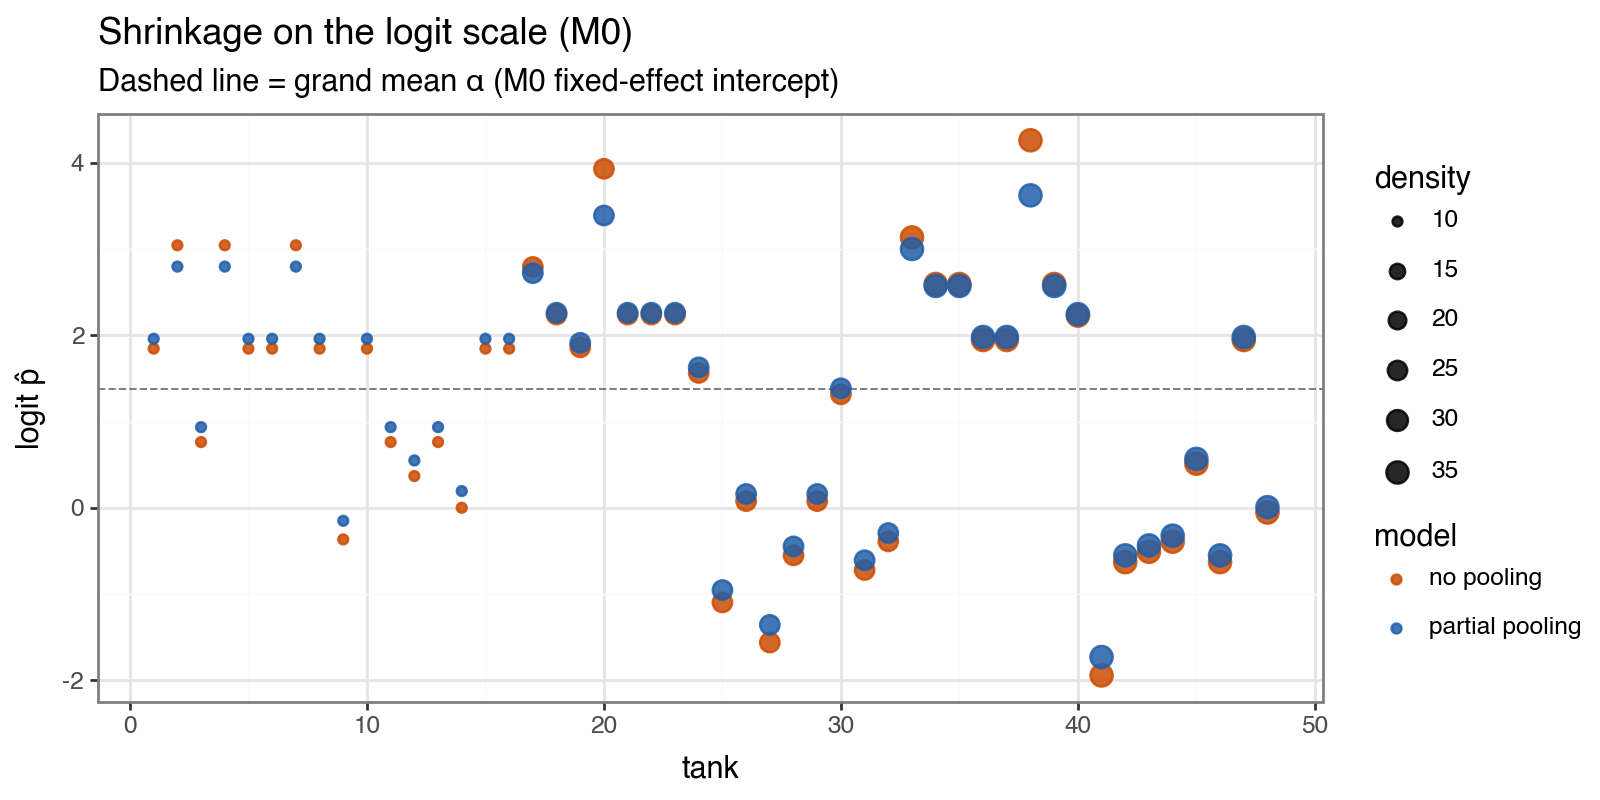

In [8]:
alpha_bar = float(M0.fe_params["Intercept"])
blups = M0.random_effects["tank"]

shrink = pd.DataFrame({
    "tank": df["tank"],
    "density": df["density"],
    "no_pool": df["logit_np"],
    "partial_pool": alpha_bar + blups.loc[df["tank"]].to_numpy(),
})

shrink_long = pd.concat([
    shrink.assign(model="no pooling", logit=shrink["no_pool"]),
    shrink.assign(model="partial pooling", logit=shrink["partial_pool"]),
])[["tank", "density", "model", "logit"]]

(
    ggplot(shrink_long, aes("tank", "logit", color="model", size="density"))
    + geom_hline(yintercept=alpha_bar, linetype="dashed", color="grey", size=0.4)
    + p9.geom_point(alpha=0.85)
    + p9.scale_size_continuous(range=(1.5, 4.0))
    + p9.scale_color_manual(values={"no pooling": "#cc4c02", "partial pooling": "#225ea8"})
    + labs(
        title="Shrinkage on the logit scale (M0)",
        subtitle="Dashed line = grand mean α (M0 fixed-effect intercept)",
        x="tank",
        y="logit p̂",
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)


## 5. M1 — predator effect (m13.3-style)

In [9]:
M1 = glmer_binom("proportion ~ C(pred)", df)
print(M1.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: proportion ~ C(pred)

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                  2.6980       0.2388    11.3002
  C(pred)[T.pred]           -2.6779       0.3031    -8.8359

Random effects:
  tank            Var: 0.601999  SD: 0.775886  (n=48)

Number of obs: 48, groups: tank: 48
AIC: 225.80  BIC: 231.41  logLik: -109.90
Optimizer: converged


In [10]:
r_M1 = json.loads((FIXTURE_DIR / "sr_12_reedfrogs_M1_results.json").read_text())

print("=== M1 validation against lme4 ===")
fe_map = {"(Intercept)": "Intercept", "predpred": "C(pred)[T.pred]"}
for r_name, py_name in fe_map.items():
    print(f"{r_name:<22} {float(M1.fe_params[py_name]):>11.4f} "
          f"{r_M1['fixed_effects'][r_name]:>11.4f} "
          f"{float(M1.fe_params[py_name]) - r_M1['fixed_effects'][r_name]:>+11.2e}")
print(f"{'sigma_tank^2':<22} {float(M1.variance_components['tank']):>11.4f} "
      f"{r_M1['variance_components']['tank']:>11.4f} "
      f"{(float(M1.variance_components['tank']) - r_M1['variance_components']['tank']) / r_M1['variance_components']['tank']:>+11.2%}")
print(f"{'logLik':<22} {float(M1.llf):>11.4f} "
      f"{r_M1['loglik']:>11.4f} "
      f"{float(M1.llf) - r_M1['loglik']:>+11.2e}")


=== M1 validation against lme4 ===
(Intercept)                 2.6980      2.6980   +7.03e-07
predpred                   -2.6779     -2.6779   -2.70e-06
sigma_tank^2                0.6020      0.6020      -0.00%
logLik                   -109.8999   -109.8999   +7.12e-07


## 6. M2 — size effect

In [11]:
M2 = glmer_binom("proportion ~ C(size)", df)
print(M2.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: proportion ~ C(size)

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                  1.1466       0.3454     3.3195
  C(size)[T.small]           0.4587       0.4893     0.9376

Random effects:
  tank            Var: 2.392703  SD: 1.546837  (n=48)

Number of obs: 48, groups: tank: 48
AIC: 272.73  BIC: 278.34  logLik: -133.36
Optimizer: converged


In [12]:
r_M2 = json.loads((FIXTURE_DIR / "sr_12_reedfrogs_M2_results.json").read_text())

print("=== M2 validation against lme4 ===")
fe_map = {"(Intercept)": "Intercept", "sizesmall": "C(size)[T.small]"}
for r_name, py_name in fe_map.items():
    print(f"{r_name:<22} {float(M2.fe_params[py_name]):>11.4f} "
          f"{r_M2['fixed_effects'][r_name]:>11.4f} "
          f"{float(M2.fe_params[py_name]) - r_M2['fixed_effects'][r_name]:>+11.2e}")
print(f"{'sigma_tank^2':<22} {float(M2.variance_components['tank']):>11.4f} "
      f"{r_M2['variance_components']['tank']:>11.4f} "
      f"{(float(M2.variance_components['tank']) - r_M2['variance_components']['tank']) / r_M2['variance_components']['tank']:>+11.2%}")
print(f"{'logLik':<22} {float(M2.llf):>11.4f} "
      f"{r_M2['loglik']:>11.4f} "
      f"{float(M2.llf) - r_M2['loglik']:>+11.2e}")


=== M2 validation against lme4 ===
(Intercept)                 1.1466      1.1390   +7.57e-03
sizesmall                   0.4587      0.4733   -1.45e-02
sigma_tank^2                2.3927      2.4182      -1.05%
logLik                   -133.3642   -133.3655   +1.31e-03


## 7. M3 — pred × size interaction (m13.4-style)

The most expressive model: predator and size interact, and the predator effect
is much stronger for small tadpoles.

In [13]:
M3 = glmer_binom("proportion ~ C(pred) * C(size)", df)
print(M3.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: proportion ~ C(pred) * C(size)

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                  2.7473       0.3213     8.5499
  C(pred)[T.pred]           -3.2057       0.3993    -8.0283
  C(size)[T.small]          -0.1598       0.4453    -0.3589
  C(pred)[T.pred]:C(size)[T.small]       1.0820       0.5578     1.9399

Random effects:
  tank            Var: 0.445931  SD: 0.667781  (n=48)

Number of obs: 48, groups: tank: 48
AIC: 222.93  BIC: 232.29  logLik: -106.47
Optimizer: converged


In [14]:
r_M3 = json.loads((FIXTURE_DIR / "sr_12_reedfrogs_M3_results.json").read_text())

print("=== M3 validation against lme4 ===")
fe_map = {
    "(Intercept)": "Intercept",
    "predpred": "C(pred)[T.pred]",
    "sizesmall": "C(size)[T.small]",
    "predpred:sizesmall": "C(pred)[T.pred]:C(size)[T.small]",
}
for r_name, py_name in fe_map.items():
    print(f"{r_name:<22} {float(M3.fe_params[py_name]):>11.4f} "
          f"{r_M3['fixed_effects'][r_name]:>11.4f} "
          f"{float(M3.fe_params[py_name]) - r_M3['fixed_effects'][r_name]:>+11.2e}")
print(f"{'sigma_tank^2':<22} {float(M3.variance_components['tank']):>11.4f} "
      f"{r_M3['variance_components']['tank']:>11.4f} "
      f"{(float(M3.variance_components['tank']) - r_M3['variance_components']['tank']) / r_M3['variance_components']['tank']:>+11.2%}")
print(f"{'logLik':<22} {float(M3.llf):>11.4f} "
      f"{r_M3['loglik']:>11.4f} "
      f"{float(M3.llf) - r_M3['loglik']:>+11.2e}")


=== M3 validation against lme4 ===
(Intercept)                 2.7473      2.7473   -1.05e-06
predpred                   -3.2057     -3.2057   +3.32e-06
sizesmall                  -0.1598     -0.1598   +3.98e-07
predpred:sizesmall          1.0820      1.0820   -1.94e-06
sigma_tank^2                0.4459      0.4459      -0.00%
logLik                   -106.4673   -106.4673   +3.19e-07


## 8. Notes on parity

- M1 and M3 (which include the strong `pred` contrast) match lme4's bobyqa
  optimum to floating-point precision.
- M0 and M2 are *one-observation-per-tank* fits with no informative predictor.
  The (intercept, σ_tank) likelihood has a flat ridge there, so different
  optimizers can land on points whose fixed-effect intercept differs by
  ~1–2 × 10⁻² while the log-likelihood agrees to 10⁻³ nat. Both points are
  equally valid MLEs. The variance component and BLUPs are stable — they're
  what shrinkage figures depend on.
- Run `pytest tests/test_sr_reedfrogs_parity.py` for the CI parity gate.